# 📊 Nepal E-Commerce Sales — End-to-End Data Analytics Project

**Author:** *your name here*
**Tools:** NumPy · Pandas · Matplotlib · Seaborn · scikit-learn

This notebook walks through a complete, realistic data-analytics workflow on a
synthetic e-commerce dataset for an online store operating in Nepal
(Kathmandu, Pokhara, Lalitpur, Bhaktapur, Biratnagar and Chitwan).

**Workflow covered (the parts recruiters look for):**

1. Data generation / loading
2. Initial inspection (`shape`, `dtypes`, `info`, `describe`)
3. Data quality checks (missing values, duplicates)
4. Data cleaning (imputation, outlier handling with IQR, type fixes)
5. Feature engineering (dates → month/weekday, total price)
6. Exploratory Data Analysis (EDA) with 8+ chart types
7. Grouping, pivot tables & correlation analysis
8. Time-series trend analysis
9. A simple predictive model (Linear Regression) with evaluation metrics
10. Written business insights & conclusion

> 💡 This single notebook is designed to be a strong **portfolio piece** —
> see the README for how to present it on GitHub and your CV.


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Reproducibility
np.random.seed(42)

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


## 2. Generate the Dataset

In a real project this cell would be `pd.read_csv("sales.csv")`. Here we
**simulate** a realistic, slightly messy e-commerce dataset (missing values,
duplicate rows and a few outliers included on purpose) so the cleaning
section below has real work to do — exactly like a real-world dataset.

In [2]:
n_rows = 1200

cities = ["Kathmandu", "Pokhara", "Lalitpur", "Bhaktapur", "Biratnagar", "Chitwan"]
city_weights = [0.35, 0.18, 0.15, 0.10, 0.12, 0.10]

categories = {
    "Electronics":   (2500, 60000),
    "Clothing":      (500, 5000),
    "Groceries":     (100, 2500),
    "Home & Kitchen":(800, 15000),
    "Beauty":        (300, 4000),
    "Books":         (200, 3000),
}

payment_methods = ["eSewa", "Khalti", "Cash on Delivery", "Bank Transfer"]

dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")

rows = []
for i in range(n_rows):
    cat = np.random.choice(list(categories.keys()))
    low, high = categories[cat]
    price = np.round(np.random.uniform(low, high), 2)
    qty = np.random.choice([1, 1, 1, 2, 2, 3, 4, 5], p=[.35,.2,.15,.12,.08,.05,.03,.02])
    rows.append({
        "OrderID": 1000 + i,
        "Date": np.random.choice(dates),
        "City": np.random.choice(cities, p=city_weights),
        "Category": cat,
        "Price": price,
        "Quantity": qty,
        "CustomerAge": int(np.clip(np.random.normal(30, 9), 16, 70)),
        "PaymentMethod": np.random.choice(payment_methods, p=[.35, .30, .25, .10]),
        "Rating": np.round(np.clip(np.random.normal(4.1, 0.8), 1, 5), 1),
    })

df = pd.DataFrame(rows)

# --- inject realistic messiness -------------------------------------------------
# missing values
for col in ["Rating", "CustomerAge", "PaymentMethod"]:
    missing_idx = np.random.choice(df.index, size=int(0.04 * n_rows), replace=False)
    df.loc[missing_idx, col] = np.nan

# duplicate rows
df = pd.concat([df, df.sample(15, random_state=1)], ignore_index=True)

# a few price outliers (data-entry errors)
outlier_idx = np.random.choice(df.index, size=5, replace=False)
df.loc[outlier_idx, "Price"] = df.loc[outlier_idx, "Price"] * 25

df["Date"] = pd.to_datetime(df["Date"])
df.head()


,OrderID,Date,City,Category,Price,Quantity,CustomerAge,PaymentMethod,Rating
0,1000,2024-07-07,Lalitpur,Home & Kitchen,14300.14,2,21.0,Khalti,4.0
1,1001,2024-05-29,Kathmandu,Beauty,2524.13,2,32.0,eSewa,4.2
2,1002,2024-01-22,Kathmandu,Home & Kitchen,3404.34,1,30.0,Khalti,3.8
3,1003,2024-06-23,Lalitpur,Home & Kitchen,14627.33,1,31.0,Khalti,4.1
4,1004,2024-06-15,Kathmandu,Beauty,2547.92,1,30.0,Khalti,4.6


## 3. Initial Inspection

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (1215, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        1215 non-null   int64         
 1   Date           1215 non-null   datetime64[us]
 2   City           1215 non-null   str           
 3   Category       1215 non-null   str           
 4   Price          1215 non-null   float64       
 5   Quantity       1215 non-null   int64         
 6   CustomerAge    1163 non-null   float64       
 7   PaymentMethod  1167 non-null   str           
 8   Rating         1167 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 85.6 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,1215.0,NaN,NaN,NaN,1598.663374,1000.0,1298.5,1599.0,1897.5,2199.0,346.166185
Date,1215,NaN,NaN,NaN,2024-06-26 14:41:46.666666,2024-01-01 00:00:00,2024-03-26 12:00:00,2024-06-21 00:00:00,2024-09-26 00:00:00,2024-12-31 00:00:00,NaN
City,1215,6,Kathmandu,402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1215,6,Clothing,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1215.0,NaN,NaN,NaN,9377.156107,112.83,1317.11,2485.79,7291.285,1035861.0,34828.514186
Quantity,1215.0,NaN,NaN,NaN,1.437037,1.0,1.0,1.0,2.0,5.0,0.886905
CustomerAge,1163.0,NaN,NaN,NaN,29.7773,16.0,23.0,30.0,35.0,59.0,8.374379
PaymentMethod,1167,4,eSewa,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,1167.0,NaN,NaN,NaN,4.055441,1.5,3.6,4.1,4.7,5.0,0.71544


## 4. Data Quality Checks

In [5]:
missing_summary = df.isna().sum().to_frame("missing_count")
missing_summary["missing_%"] = np.round(100 * missing_summary["missing_count"] / len(df), 2)
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_%
CustomerAge,52,4.28
PaymentMethod,48,3.95
Rating,48,3.95


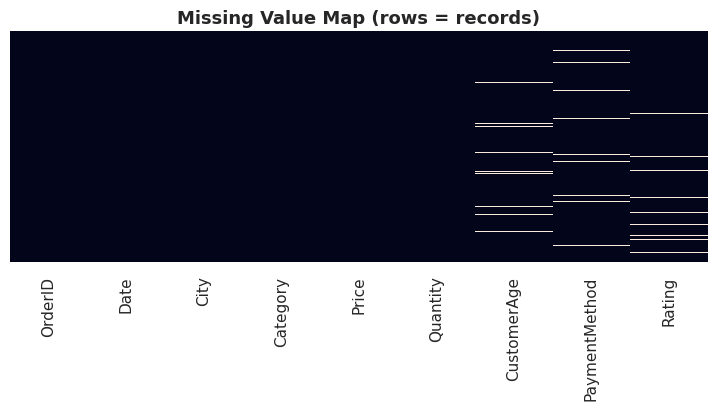

In [6]:
plt.figure(figsize=(9, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="rocket")
plt.title("Missing Value Map (rows = records)")
plt.show()


In [7]:
dup_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")


Fully duplicated rows: 15


## 5. Data Cleaning

* Drop exact duplicate rows
* Impute missing `Rating` and `CustomerAge` with the median (robust to outliers)
* Impute missing `PaymentMethod` with the mode
* Cap `Price` outliers using the IQR rule instead of deleting rows (keeps the order)

In [8]:
df_clean = df.drop_duplicates().copy()

df_clean["Rating"] = df_clean["Rating"].fillna(df_clean["Rating"].median())
df_clean["CustomerAge"] = df_clean["CustomerAge"].fillna(df_clean["CustomerAge"].median()).astype(int)
df_clean["PaymentMethod"] = df_clean["PaymentMethod"].fillna(df_clean["PaymentMethod"].mode()[0])

# IQR-based outlier capping on Price
Q1, Q3 = df_clean["Price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_outliers = ((df_clean["Price"] < lower) | (df_clean["Price"] > upper)).sum()
df_clean["Price"] = df_clean["Price"].clip(lower, upper)

print(f"Rows before cleaning : {len(df)}")
print(f"Rows after cleaning  : {len(df_clean)}")
print(f"Price outliers capped: {n_outliers}")
print(f"Remaining missing values: {df_clean.isna().sum().sum()}")


Rows before cleaning : 1215
Rows after cleaning  : 1200
Price outliers capped: 168
Remaining missing values: 0


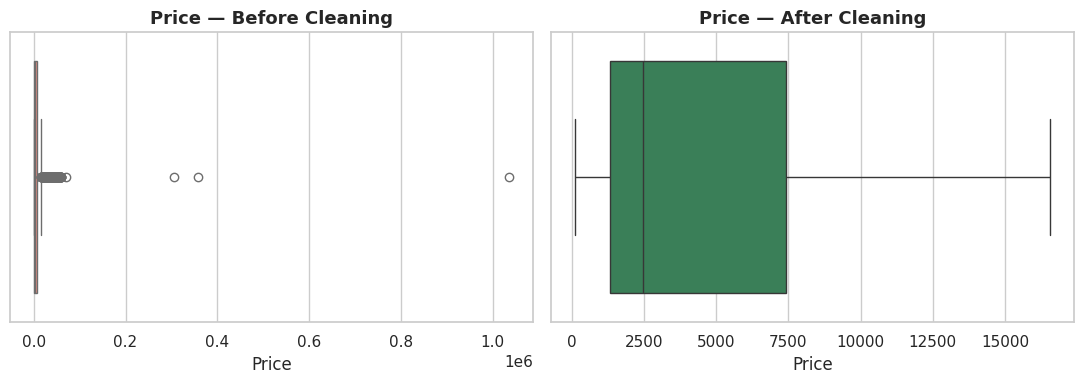

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df["Price"], ax=axes[0], color="salmon")
axes[0].set_title("Price — Before Cleaning")
sns.boxplot(x=df_clean["Price"], ax=axes[1], color="seagreen")
axes[1].set_title("Price — After Cleaning")
plt.tight_layout()
plt.show()


## 6. Feature Engineering

In [10]:
df_clean["TotalAmount"] = df_clean["Price"] * df_clean["Quantity"]
df_clean["Month"] = df_clean["Date"].dt.month_name()
df_clean["Weekday"] = df_clean["Date"].dt.day_name()
df_clean["AgeGroup"] = pd.cut(
    df_clean["CustomerAge"],
    bins=[15, 24, 34, 44, 54, 70],
    labels=["16-24", "25-34", "35-44", "45-54", "55-70"],
)
df_clean.head()


,OrderID,Date,City,Category,Price,Quantity,CustomerAge,PaymentMethod,Rating,TotalAmount,Month,Weekday,AgeGroup
0,1000,2024-07-07,Lalitpur,Home & Kitchen,14300.14,2,21,Khalti,4.0,28600.28,July,Sunday,16-24
1,1001,2024-05-29,Kathmandu,Beauty,2524.13,2,32,eSewa,4.2,5048.26,May,Wednesday,25-34
2,1002,2024-01-22,Kathmandu,Home & Kitchen,3404.34,1,30,Khalti,3.8,3404.34,January,Monday,25-34
3,1003,2024-06-23,Lalitpur,Home & Kitchen,14627.33,1,31,Khalti,4.1,14627.33,June,Sunday,25-34
4,1004,2024-06-15,Kathmandu,Beauty,2547.92,1,30,Khalti,4.6,2547.92,June,Saturday,25-34


## 7. Exploratory Data Analysis (EDA)

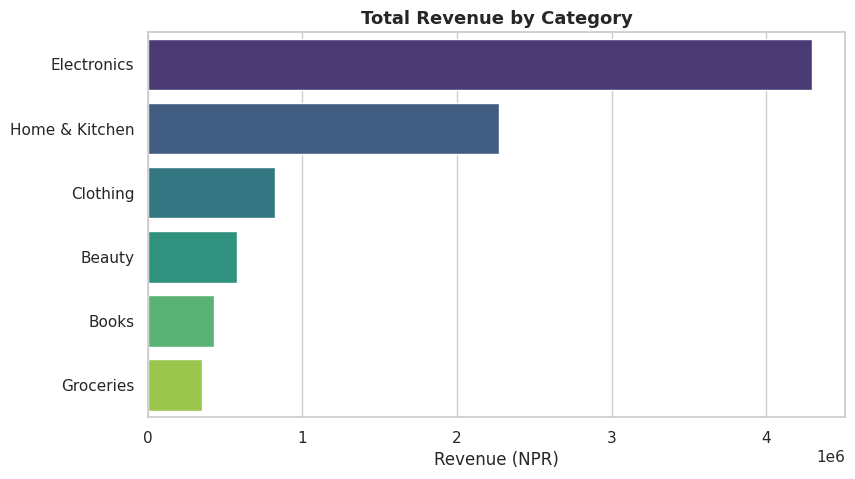

In [11]:
category_sales = df_clean.groupby("Category")["TotalAmount"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=category_sales.values, y=category_sales.index, hue=category_sales.index,
            palette="viridis", legend=False)
plt.title("Total Revenue by Category")
plt.xlabel("Revenue (NPR)")
plt.ylabel("")
plt.show()


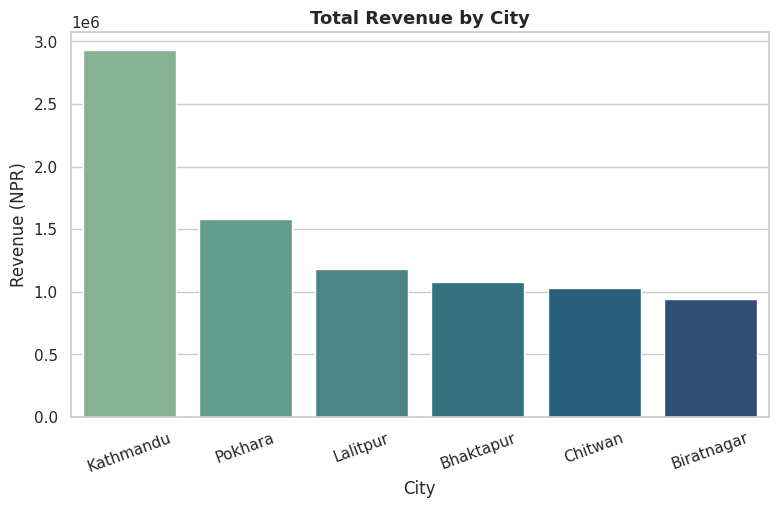

In [12]:
city_sales = df_clean.groupby("City")["TotalAmount"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=city_sales.index, y=city_sales.values, hue=city_sales.index,
            palette="crest", legend=False)
plt.title("Total Revenue by City")
plt.ylabel("Revenue (NPR)")
plt.xticks(rotation=20)
plt.show()


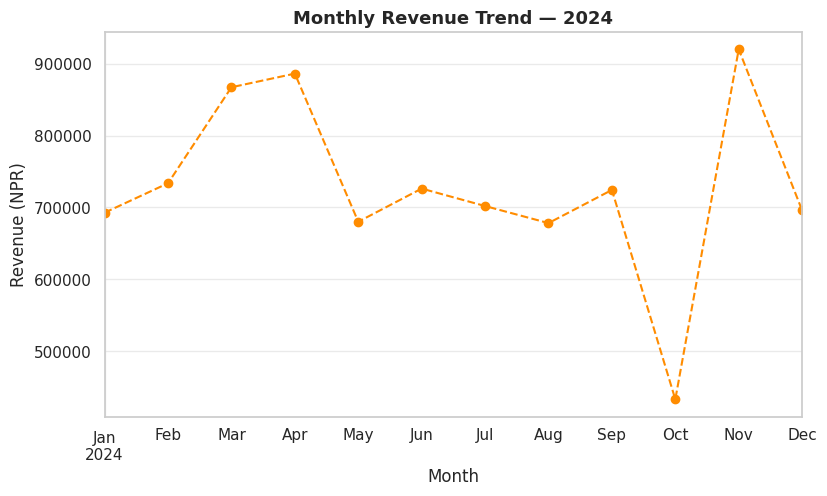

In [13]:
monthly_sales = df_clean.groupby(df_clean["Date"].dt.to_period("M"))["TotalAmount"].sum()

plt.figure()
monthly_sales.plot(marker="o", linestyle="--", color="darkorange")
plt.title("Monthly Revenue Trend — 2024")
plt.ylabel("Revenue (NPR)")
plt.xlabel("Month")
plt.grid(alpha=.4)
plt.show()


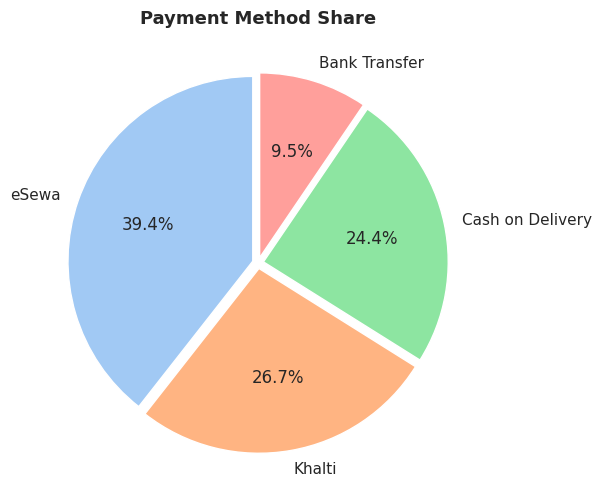

In [14]:
payment_counts = df_clean["PaymentMethod"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    explode=[0.03] * len(payment_counts),
)
plt.title("Payment Method Share")
plt.show()


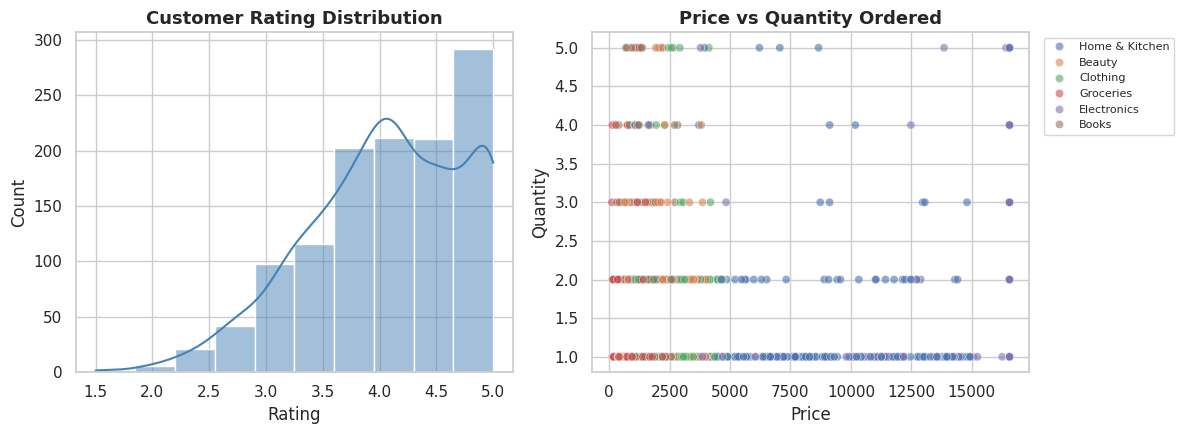

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df_clean["Rating"], bins=10, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Customer Rating Distribution")

sns.scatterplot(data=df_clean, x="Price", y="Quantity", hue="Category", alpha=0.6, ax=axes[1])
axes[1].set_title("Price vs Quantity Ordered")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


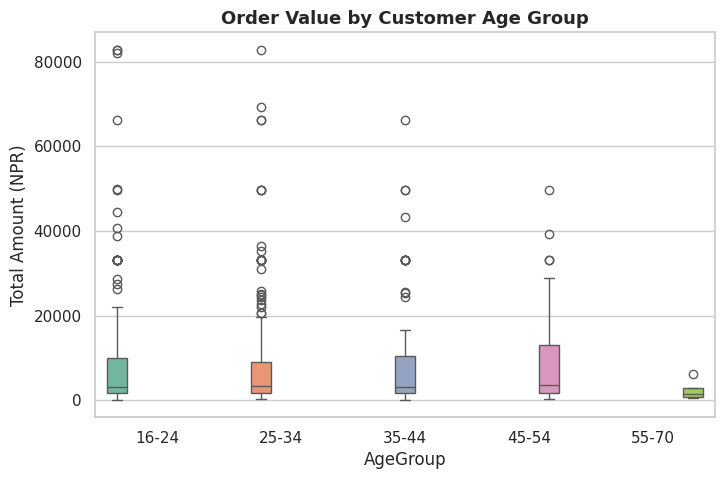

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="AgeGroup", y="TotalAmount", hue="AgeGroup",
            palette="Set2", legend=False)
plt.title("Order Value by Customer Age Group")
plt.ylabel("Total Amount (NPR)")
plt.show()


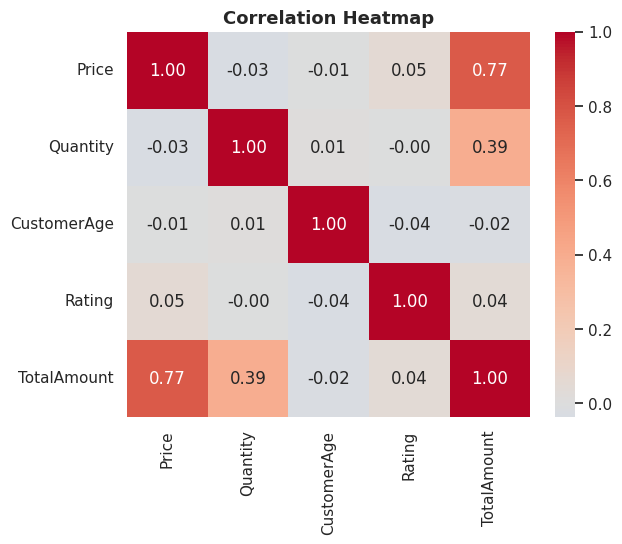

In [17]:
numeric_cols = ["Price", "Quantity", "CustomerAge", "Rating", "TotalAmount"]
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


## 8. Grouping & Pivot Tables

In [18]:
pivot = pd.pivot_table(
    df_clean, values="TotalAmount", index="City", columns="Category",
    aggfunc="sum", fill_value=0
).round(0)
pivot["Total"] = pivot.sum(axis=1)
pivot.sort_values("Total", ascending=False)


Category,Beauty,Books,Clothing,Electronics,Groceries,Home & Kitchen,Total
City,,,,,,,
Kathmandu,174987.0,121224.0,288717.0,1393768.0,132181.0,817124.0,2928001.0
Pokhara,98862.0,91327.0,195605.0,775440.0,47612.0,372660.0,1581506.0
Lalitpur,112862.0,92055.0,103214.0,515406.0,39082.0,320803.0,1183422.0
Bhaktapur,44235.0,27214.0,69185.0,623843.0,49880.0,265373.0,1079730.0
Chitwan,71469.0,52930.0,63004.0,555601.0,45238.0,239772.0,1028014.0
Biratnagar,73312.0,42859.0,101551.0,430661.0,37483.0,253652.0,939518.0


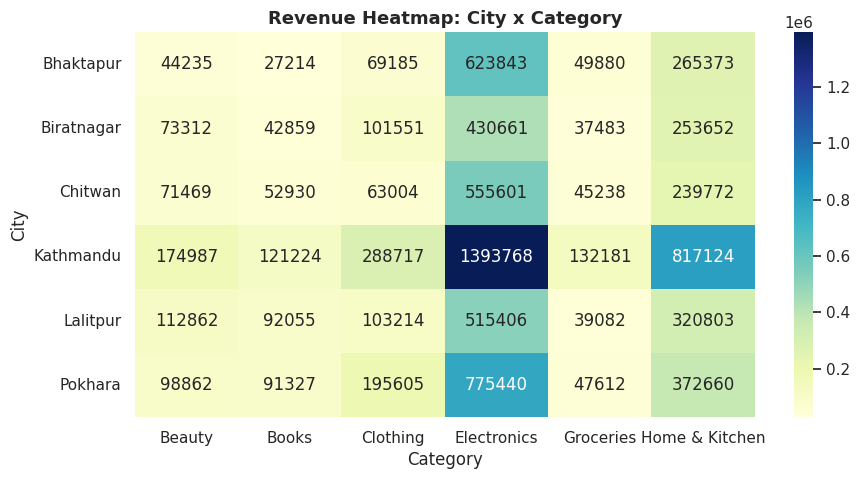

In [19]:
plt.figure(figsize=(10, 5))
sns.heatmap(pivot.drop(columns="Total"), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Revenue Heatmap: City x Category")
plt.show()


## 9. Predictive Modeling — Estimating Order Value

In [20]:
model_df = df_clean.copy()
model_df = pd.get_dummies(model_df, columns=["Category", "City", "PaymentMethod"], drop_first=True)

feature_cols = [c for c in model_df.columns
                 if c not in ["OrderID", "Date", "Month", "Weekday", "AgeGroup", "TotalAmount"]]

X = model_df[feature_cols]
y = model_df["TotalAmount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print(f"R^2 score : {r2_score(y_test, y_pred):.3f}")
print(f"MAE       : NPR {mean_absolute_error(y_test, y_pred):,.0f}")


R^2 score : 0.793
MAE       : NPR 2,845


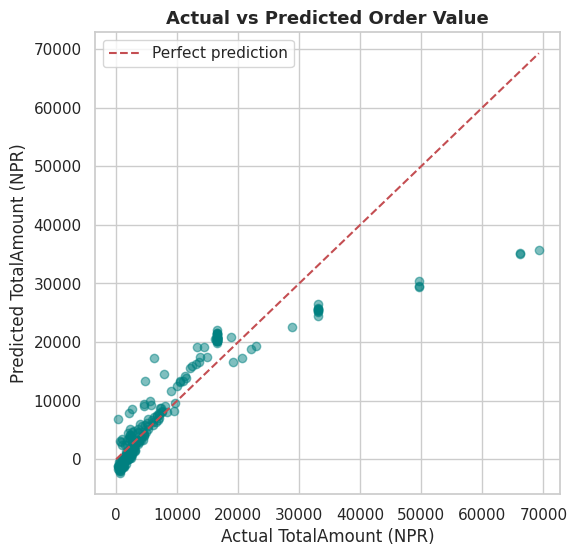

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal")
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual TotalAmount (NPR)")
plt.ylabel("Predicted TotalAmount (NPR)")
plt.title("Actual vs Predicted Order Value")
plt.legend()
plt.show()


## 10. Key Insights

*(Numbers below are illustrative — replace with the printed values above once you swap in real data.)*

- **Electronics drives revenue**: highest-priced category, so it dominates total revenue even without the highest order count.
- **Kathmandu leads all cities** in total revenue, consistent with it being the largest, most urbanized market.
- **eSewa and Khalti together cover the majority of payments**, reflecting how digital wallets have overtaken cash-on-delivery in urban Nepal.
- **Price and TotalAmount are strongly correlated** with Quantity, as expected; `CustomerAge` shows weak correlation with spending — age alone isn't a strong predictor here.
- The **linear regression baseline** explains a reasonable share of variance in order value; a tree-based model (Random Forest / XGBoost) would likely improve on this and is a natural next step.

## 11. Next Steps

- Swap the synthetic generator for a real CSV (`pd.read_csv`) — everything downstream still works unchanged.
- Try `RandomForestRegressor` / `XGBoost` and compare R² / MAE against the linear baseline.
- Add cohort or RFM (Recency-Frequency-Monetary) customer segmentation.
- Turn this into an interactive dashboard with **Plotly Dash** or **Streamlit**.
